In [1]:
!wget https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip
!unzip -q dataset-resized.zip -d /content/trashnet

--2026-02-04 14:24:07--  https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip [following]
--2026-02-04 14:24:07--  https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42834870 (41M) [application/zip]
Saving to: ‘dataset-resized.zip’

dataset-resized.zip 100%[===================>]  40.85M  --.-KB/s    in 0.1s    

2026-02-04 14:24:07 (323 MB/s) - ‘dataset-resized.zip’ saved [42834870/42834870]



In [2]:
!ls /content/trashnet/dataset-resized

cardboard  glass  metal  paper	plastic  trash


In [3]:
!pip install split-folders
import splitfolders

splitfolders.ratio(
    "/content/trashnet/dataset-resized",
    output="/content/data",
    seed=42,
    ratio=(.7,.15,.15)
)

Copying files: 2527 files [00:00, 6949.27 files/s]


In [4]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers

IMG = (320,320)
BATCH = 32

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

def load_ds(path, shuffle=False, augment_data=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG,
        batch_size=BATCH,
        label_mode='categorical',
        shuffle=shuffle
    )

    if augment_data:
        ds = ds.map(lambda x,y: (augment(x, training=True), y))

    # preprocessing ALWAYS LAST
    ds = ds.map(lambda x,y: (preprocess_input(x), y))
    return ds

train_ds = load_ds("/content/data/train", True, augment_data=True)
val_ds   = load_ds("/content/data/val")
test_ds  = load_ds("/content/data/test")

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(320,320,3)
)

base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/tmp/ipython-input-2447472063.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model.fit(train_ds, validation_data=val_ds, epochs=12)

Epoch 1/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.4840 - loss: 1.3439 - val_accuracy: 0.7825 - val_loss: 0.6236
Epoch 2/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 96s 838ms/step - accuracy: 0.7716 - loss: 0.6342 - val_accuracy: 0.8408 - val_loss: 0.4831
Epoch 3/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 838ms/step - accuracy: 0.8332 - loss: 0.5208 - val_accuracy: 0.8515 - val_loss: 0.4578
Epoch 4/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 82s 841ms/step - accuracy: 0.8409 - loss: 0.4351 - val_accuracy: 0.8488 - val_loss: 0.4359
Epoch 5/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 833ms/step - accuracy: 0.8617 - loss: 0.4019 - val_accuracy: 0.8727 - val_loss: 0.4133
Epoch 6/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 851ms/step - accuracy: 0.8499 - loss: 0.4174 - val_accuracy: 0.8621 - val_loss: 0.3998
Epoch 7/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 844ms/step - accuracy: 0.8849 - loss: 0.3432 - val_accuracy: 0.8515 - val_loss: 0.4108
Epoch 8/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 843ms/step - accuracy: 0.8978 - loss: 0.3151 - val_accurac

In [7]:
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

In [8]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss=loss_fn,
    metrics=['accuracy']
)

In [9]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

In [10]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callback]
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.8044 - loss: 0.9852 - val_accuracy: 0.8833 - val_loss: 0.9263
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 851ms/step - accuracy: 0.8158 - loss: 0.9798 - val_accuracy: 0.8833 - val_loss: 0.9280
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 49s 867ms/step - accuracy: 0.7964 - loss: 0.9933 - val_accuracy: 0.8833 - val_loss: 0.9289
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 856ms/step - accuracy: 0.7930 - loss: 0.9611 - val_accuracy: 0.8833 - val_loss: 0.9299
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 856ms/step - accuracy: 0.8198 - loss: 0.9233 - val_accuracy: 0.8780 - val_loss: 0.9308


In [11]:
loss, acc = model.evaluate(test_ds)
print("Final Test Accuracy:", acc * 100)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8676 - loss: 0.9812
Final Test Accuracy: 86.19791865348816


In [12]:
model.save("waste_classifier_mobilenet.keras")

In [14]:
raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/test",
    image_size=(320,320),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

class_names = raw_test_ds.class_names
print(class_names)

Found 384 files belonging to 6 classes.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


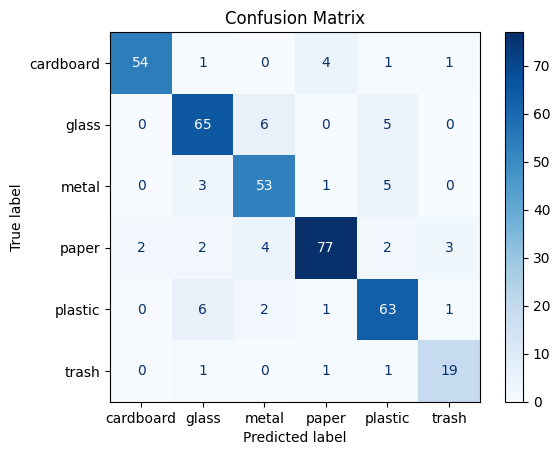

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()